In [1]:
import numpy as np
import pandas as pd
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import heapq

from joblib import Parallel, delayed
from scipy import stats
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
num_pnts = 10
runs = 1
infection_model = 'acute'
sample_virs = np.array(np.meshgrid(d_S*np.linspace(1, 100, num_pnts), # vary d_I
                                   S_0*np.logspace(-3.0, 0, num_pnts), # vary K_I
                                   b_I*np.linspace(0.5, 2.0, num_pnts), # vary b_I
                                   K_H*np.array([1.0]), # vary K_H
                                   N_0*np.logspace(-1, 1, num_pnts), # vary N_0
                                   I_min*np.array([1.0]) # vary I_0
                                       )).T.reshape(-1,6)

Na_regulation = [2.0, 2.0, -2.0, -0.5*L0_max]
NE_regulation = [2, 2, -2.0, 0.25*L0_max]
EM_regulation = [-0, -0, 0, -L0_max**3]
Edie_regulation = [-2, -2, 2.0, -0.5*L0_max]
default_reg = np.array([Na_regulation + NE_regulation + EM_regulation + Edie_regulation])

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw"
# d="_local_data/"

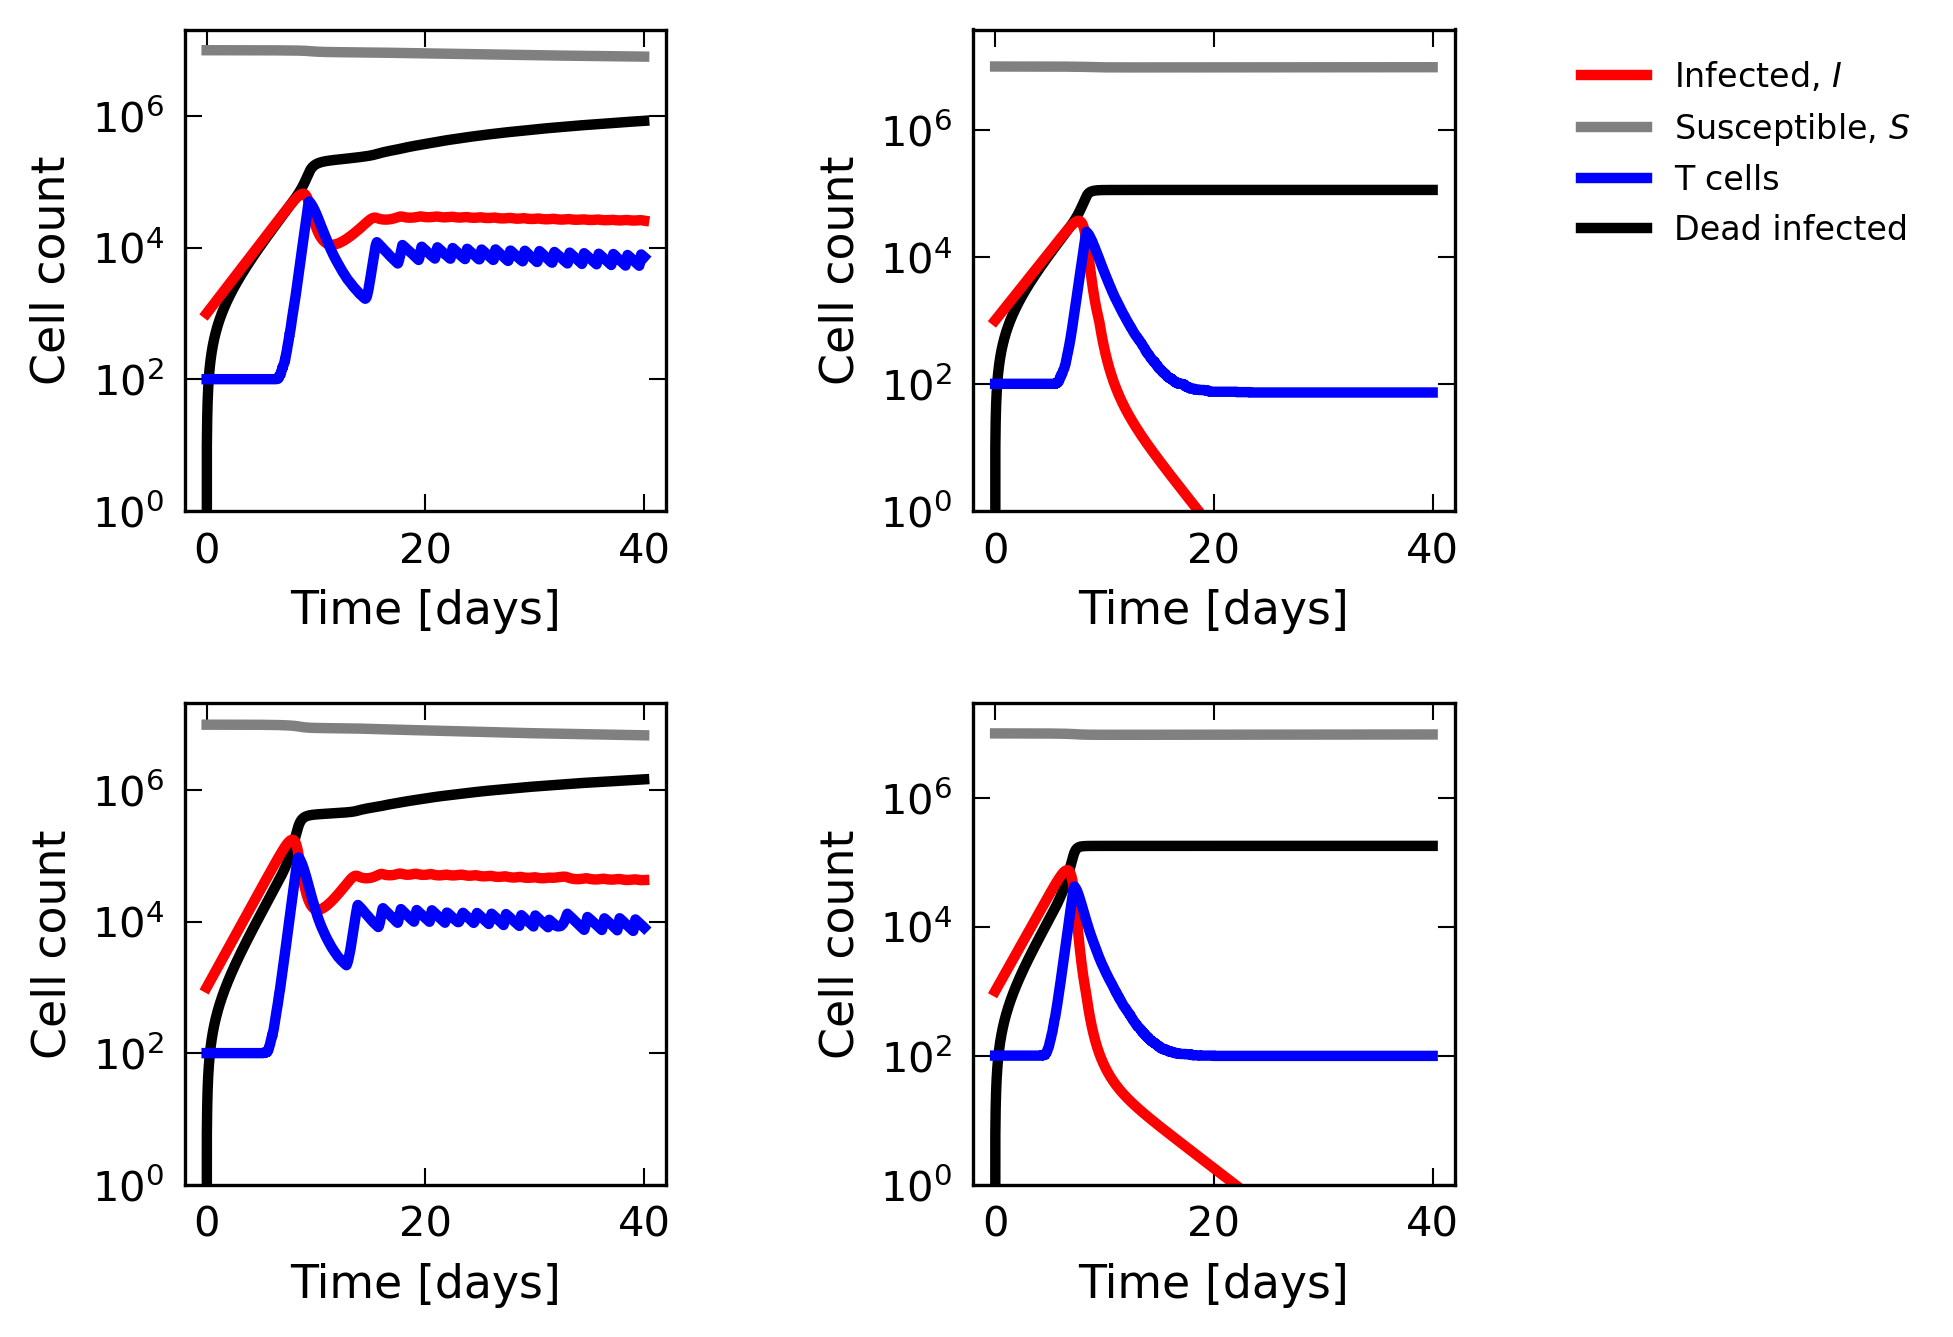

In [3]:
# Plot select infection responses
fig, axs = plt.subplots(2,2, dpi = 150, sharex = False, sharey = False, figsize=(6,5))

scenarios = np.array(np.meshgrid(np.array([heapq.nlargest(6, np.unique(infection_sample[:,0]))[5], heapq.nsmallest(6, np.unique(infection_sample[:,0]))[2]]), # vary d_I
                                 np.array([heapq.nlargest(6, np.unique(infection_sample[:,1]))[5], heapq.nsmallest(6, np.unique(infection_sample[:,1]))[2]]), # vary K_I
                                 np.array([np.amax(infection_sample[:,2])]), # vary b_I
                                 np.array([np.amax(infection_sample[:,3])]), # vary K_H
                                 np.array([np.amax(infection_sample[:,4])]), # vary N_0
                                 np.array([np.amax(infection_sample[:,5])]) # vary I_0
                                           )).T.reshape(-1,6)

var_labels = ["antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", 
              "lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
labels = ['low ' + var_labels[0]+' fast '+var_labels[1],
          'high ' + var_labels[0]+' fast '+var_labels[1],
          'low ' + var_labels[0]+' slow '+var_labels[1],
          'high ' + var_labels[0]+' slow '+var_labels[1]]
cmap_colors = sns.color_palette('tab20', 20)

# Loop and do 
for k, v in enumerate(scenarios):
    y, x = k % 2, k // 2

    # Run single simulation
    data_dict = lin_stoch_sim(N_0 = v[4],
                              I_0 = v[5],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              NE_regulation = NE_regulation,
                              EM_regulation = EM_regulation,
                              activation_regulation = Na_regulation,
                              contraction_regulation = Edie_regulation,
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    # Plot cell dynamics
    axs[x,y].plot(ts, I, 'r', label = r'Infected, $I$', linewidth=2.5)
    axs[x,y].plot(ts, S, 'grey', label = r'Susceptible, $S$', linewidth=2.5)
    axs[x,y].plot(ts, N + Na + E + M, 'blue', linewidth=2.5, label = r'T cells')
    axs[x,y].plot(ts, I_d_I, 'black', zorder = 1, linewidth=2.5, label = r'Dead infected')

    # axs[x,y].set_title(labels[k], fontsize = 8.0, pad = 0.1)
    axs[x,y].set_box_aspect(1)
    axs[x,y].semilogy()
    axs[x,y].minorticks_off()
    axs[x,y].set_ylim(1,)

for j, ax in enumerate(axs.flat):
    if j == 1:
        ax.legend(bbox_to_anchor=(1.2, 1), framealpha=0, ncol = 1, fontsize = 8)
    ax.set_ylabel('Cell count', fontsize = 11)
    ax.set_xlabel(r"Time [days]", fontsize = 11)
fig.subplots_adjust(wspace=.3, hspace=0.40)

plt.savefig('_figs/'+infection_model+'-scenarios-of-infection-dynamics-simple.png', dpi=300, bbox_inches="tight")

/mmfs1/home/oukogu/infoimmune/stoch_sim_model.py:526: RuntimeWarning: invalid value encountered in scalar divide
  selection_ratio = -np.sum(div_E_count*np.log10(p_tcr))/np.sum(div_E_count)


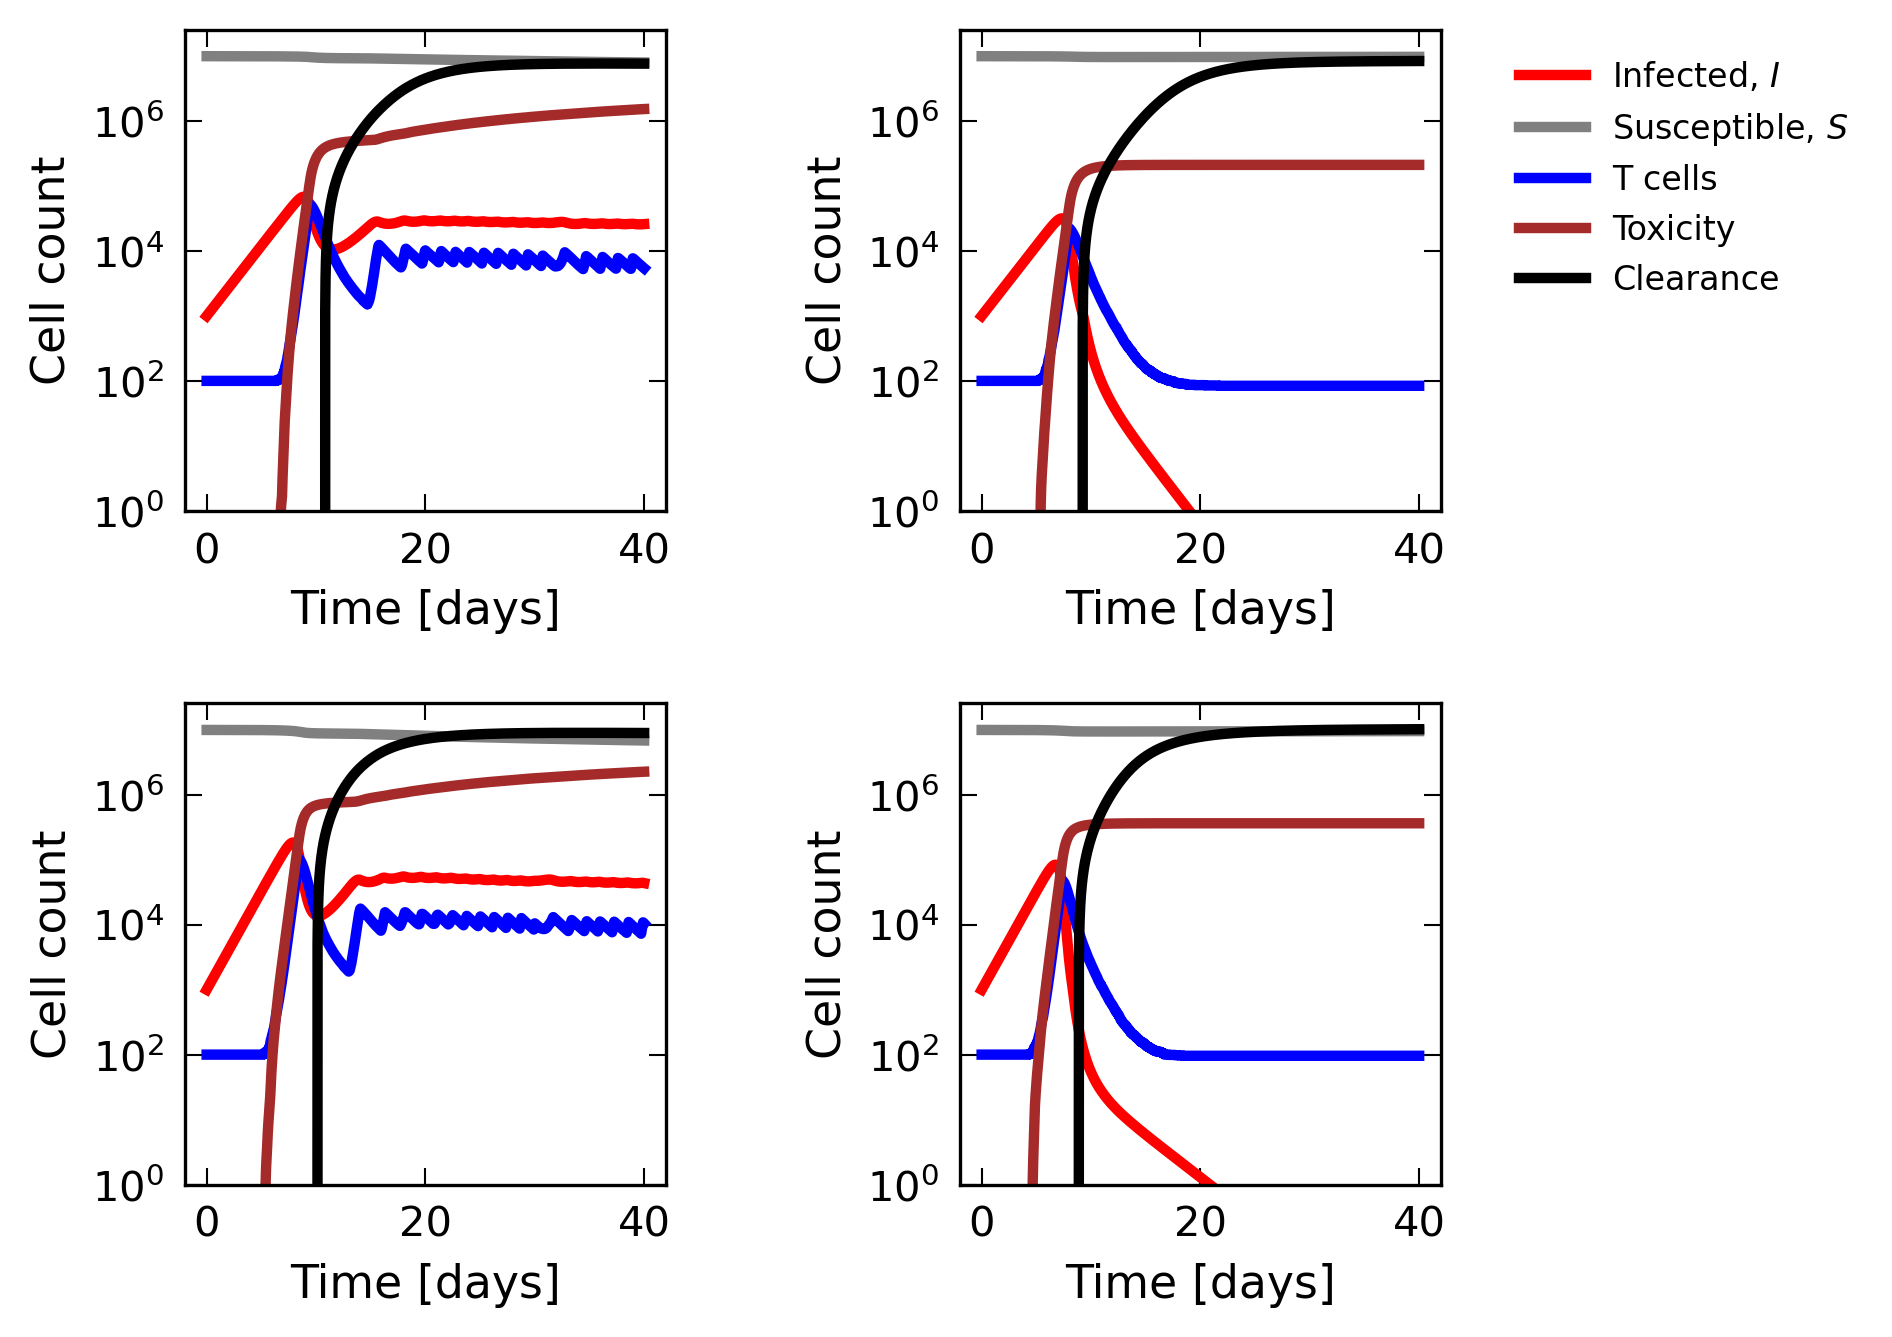

In [4]:
# Plot select infection responses
fig, axs = plt.subplots(2,2, dpi = 150, sharex = True, sharey = True, figsize=(6,5))

scenarios = np.array(np.meshgrid(np.array([heapq.nlargest(6, np.unique(infection_sample[:,0]))[5], heapq.nsmallest(6, np.unique(infection_sample[:,0]))[2]]), # vary d_I
                                 np.array([heapq.nlargest(6, np.unique(infection_sample[:,1]))[5], heapq.nsmallest(6, np.unique(infection_sample[:,1]))[2]]), # vary K_I
                                 np.array([np.amax(infection_sample[:,2])]), # vary b_I
                                 np.array([np.amax(infection_sample[:,3])]), # vary K_H
                                 np.array([np.amax(infection_sample[:,4])]), # vary N_0
                                 np.array([np.amax(infection_sample[:,5])]) # vary I_0
                                           )).T.reshape(-1,6)

var_labels = ["antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", 
              "lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
labels = ['low ' + var_labels[0]+' fast '+var_labels[1],
          'high ' + var_labels[0]+' fast '+var_labels[1],
          'low ' + var_labels[0]+' slow '+var_labels[1],
          'high ' + var_labels[0]+' slow '+var_labels[1]]
cmap_colors = sns.color_palette('tab20', 20)

# Loop and do 
for k, v in enumerate(scenarios):
    y, x = k % 2, k // 2

    # Run single simulation
    data_dict = lin_stoch_sim(N_0 = v[4],
                              I_0 = v[5],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              NE_regulation = NE_regulation,
                              EM_regulation = EM_regulation,
                              activation_regulation = Na_regulation,
                              contraction_regulation = Edie_regulation,
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    # Plot cell dynamics
    axs[x,y].plot(ts, I, 'r', label = r'Infected, $I$', linewidth=2.5)
    axs[x,y].plot(ts, S, 'grey', label = r'Susceptible, $S$', linewidth=2.5)
    axs[x,y].plot(ts, N + Na + E + M, 'blue', linewidth=2.5, label = r'T cells')
    axs[x,y].plot(ts, I_d_S, 'brown', linewidth=2.5, label = r'Toxicity')
    # axs[x,y].plot(ts, I_d_I, 'black', linewidth=2.5, label = r'Dead infected')

    # Run simulation without immune cells
    data_dict = lin_stoch_sim(N_0 = 0.0,
                              I_0 = v[5],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              NE_regulation = NE_regulation,
                              EM_regulation = EM_regulation,
                              activation_regulation = Na_regulation,
                              contraction_regulation = Edie_regulation,
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    
    S, I, N, Na, E, M, HI, I_d_I_noimm, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    axs[x,y].plot(ts, I_d_I_noimm - I_d_I, 'black', linewidth=2.5, linestyle = '-', label = r'Clearance')

    # axs[x,y].set_title(labels[k], fontsize = 8.0, pad = 0.1)
    axs[x,y].set_box_aspect(1)
    axs[x,y].semilogy()
    axs[x,y].minorticks_off()
    axs[x,y].set_ylim(1,)
    axs[x,y].xaxis.set_tick_params(labelbottom=True)
    axs[x,y].yaxis.set_tick_params(labelleft=True)

for j, ax in enumerate(axs.flat):
    if j == 1:
        ax.legend(bbox_to_anchor=(1.1, 1), framealpha=0, ncol = 1, fontsize = 8) # 
    ax.set_ylabel('Cell count', fontsize = 11)
    ax.set_xlabel(r"Time [days]", fontsize = 11)
fig.subplots_adjust(wspace=.25, hspace=0.40)

plt.savefig('_figs/'+infection_model+'-scenarios-of-infection-dynamics.png', dpi=300, bbox_inches="tight")

In [5]:
n_steps = 7
p_default = np.array([0.1*Na_regulation[0], 0.1*Na_regulation[1], 0.10*Na_regulation[2], Na_regulation[3], NE_regulation[3], Edie_regulation[3], 0.0])
vary_ps = np.tile(p_default,  (n_steps*(len(p_default) - 1), 1))

for i in np.arange(len(p_default) - 1):
    vary_ps[i*n_steps:(i+1)*n_steps, i] = np.linspace(-L0_max, L0_max, n_steps)
    vary_ps[i*n_steps:(i+1)*n_steps, -1] = i

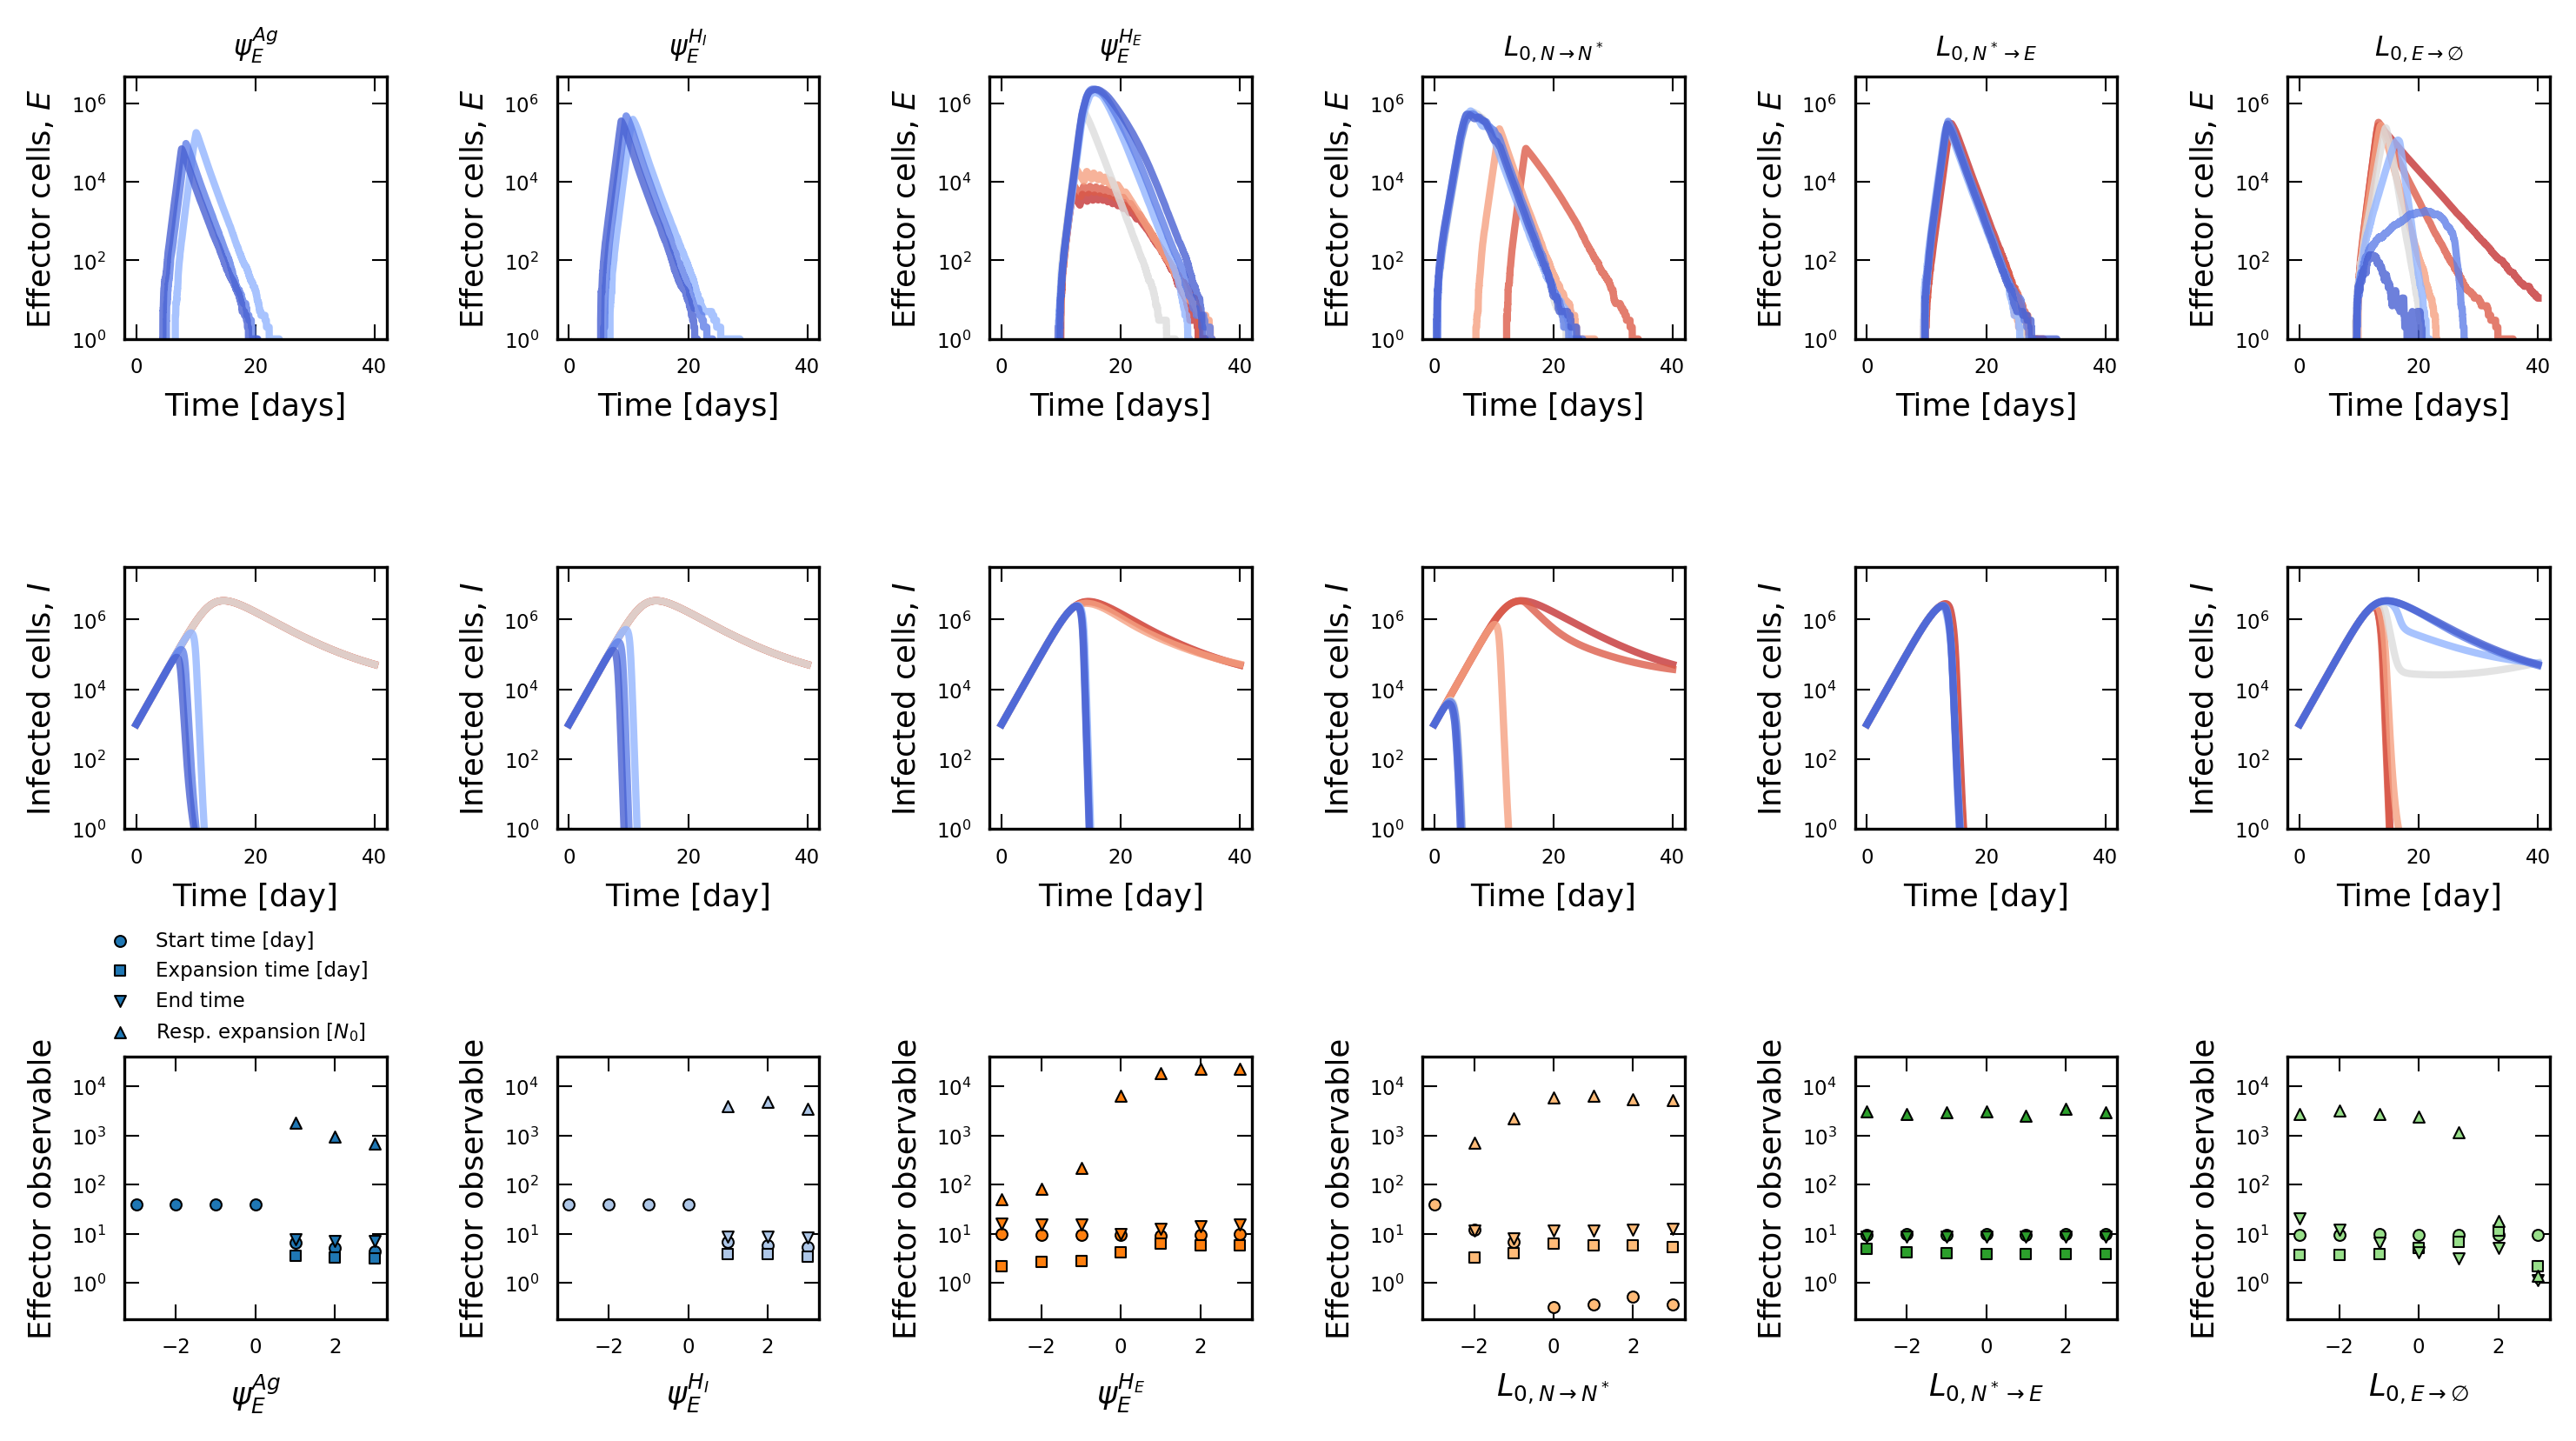

In [6]:
# Plot select infection responses
fig, axs = plt.subplots(3,len(opt_vars), dpi = 150, sharex = 'row', sharey = 'row', figsize=(2*len(opt_vars), 7))

store_runs = []
# Loop and do 
for k, p in enumerate(vary_ps):
    # if k % 3 == 0:
    # Vary pareto designs
    index = int(p[-1])
    data_dict = lin_stoch_sim(N_0 = v[4],
                              I_0 = v[5],
                              b_I = v[2], 
                              K_I = v[1],
                              d_I = v[0],
                              K_H = v[3],
                              NE_regulation = [p[0], p[1], p[2], p[4]],
                              EM_regulation = [-0*p[0], -0*p[1], -0*p[2], -L0_max],
                              activation_regulation = [p[0], p[1], p[2], p[3]],
                              contraction_regulation = [-p[0], -p[1], -p[2], p[5]],
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False,
                              duration = 1.0*sim_duration,
                              steps = 1*sim_steps)
    
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    sim_summary = data_dict["summary_stats"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]

    # Plot cell dynamics
    axs[0, index].plot(ts, E, linewidth=2.0, color = plt.cm.coolwarm_r(1/(1 + np.exp(-p[index]))), alpha = 0.8)
    axs[1, index].plot(ts, I, linewidth=2.0, color = plt.cm.coolwarm_r(1/(1 + np.exp(-p[index]))), alpha = 0.8)
    axs[2, index].scatter(p[index], sim_summary[7], color = cmap_colors[index], linewidths = 0.5,
                          marker = reg_markers[0], s = 9.5, ec = 'black', label = 'Start time [day]' if k == 0 else '') #Effector start time
    axs[2, index].scatter(p[index], sim_summary[6] - sim_summary[7], color = cmap_colors[index], linewidths = 0.5,
                          marker = reg_markers[1], ec = 'black', s = 9.5, label = 'Expansion time [day]' if k == 0 else '') # Effector peak time
    axs[2, index].scatter(p[index], (sim_summary[10] - sim_summary[6]), color = cmap_colors[index], linewidths = 0.5,
                          marker = reg_markers[2], ec = 'black', s = 9.5, label = 'End time' if k == 0 else '') # Effector end time
    axs[2, index].scatter(p[index], np.amax(E)/v[4], color = cmap_colors[index], linewidths = 0.5,
                          marker = reg_markers[3], ec = 'black', s = 9.5, label = r'Resp. expansion [$N_0$]' if k == 0 else '') # Effector peak magnitude
    
    axs[0, index].set_title(opt_vars_labels[index], fontsize = 7.5)

    store_runs.append( (p.tolist() + [sim_summary[7], sim_summary[6] - sim_summary[7], sim_summary[10] - sim_summary[6], np.amax(E)/v[4], sim_summary[8]/v[4], sim_summary[9]]) )

axs[2, 0].legend(bbox_to_anchor=(1.0, 1.55), fontsize=5.5, framealpha=0, ncol = 1)

for j, ax in enumerate(axs.flat):
    ax.set_box_aspect(1)
    if j // len(opt_vars) == 0:
        ax.set_ylabel(r'Effector cells, $E$', fontsize = 8.5)
        ax.set_xlabel(r"Time [days]", fontsize = 8.5)
        ax.semilogy()
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylim(1,)
    elif j // len(opt_vars) == 1:
        ax.set_ylabel(r'Infected cells, $I$', fontsize = 8.5)
        ax.set_xlabel(r"Time [day]", fontsize = 8.5)
        ax.semilogy()
        ax.locator_params(axis='x', nbins=4)
        ax.set_ylim(1,)
    else:
        ax.set_xlabel(opt_vars_labels[j % len(opt_vars)], fontsize = 8.5)
        #ax.locator_params(axis='x', nbins=4)
        ax.set_ylabel("Effector observable", fontsize = 8.5)
        ax.semilogy()
        #ax.set_yscale('symlog')

    ax.minorticks_off()
    ax.tick_params(axis='both', which='major', labelsize=5.5)
    ax.xaxis.set_tick_params(labelbottom=True)
    ax.yaxis.set_tick_params(labelleft=True)

fig.subplots_adjust(wspace=.65, hspace=0.15)

plt.savefig('_figs/'+infection_model+'-example-design-ablate-eff-dynamics'+'.png', dpi=300, bbox_inches="tight")

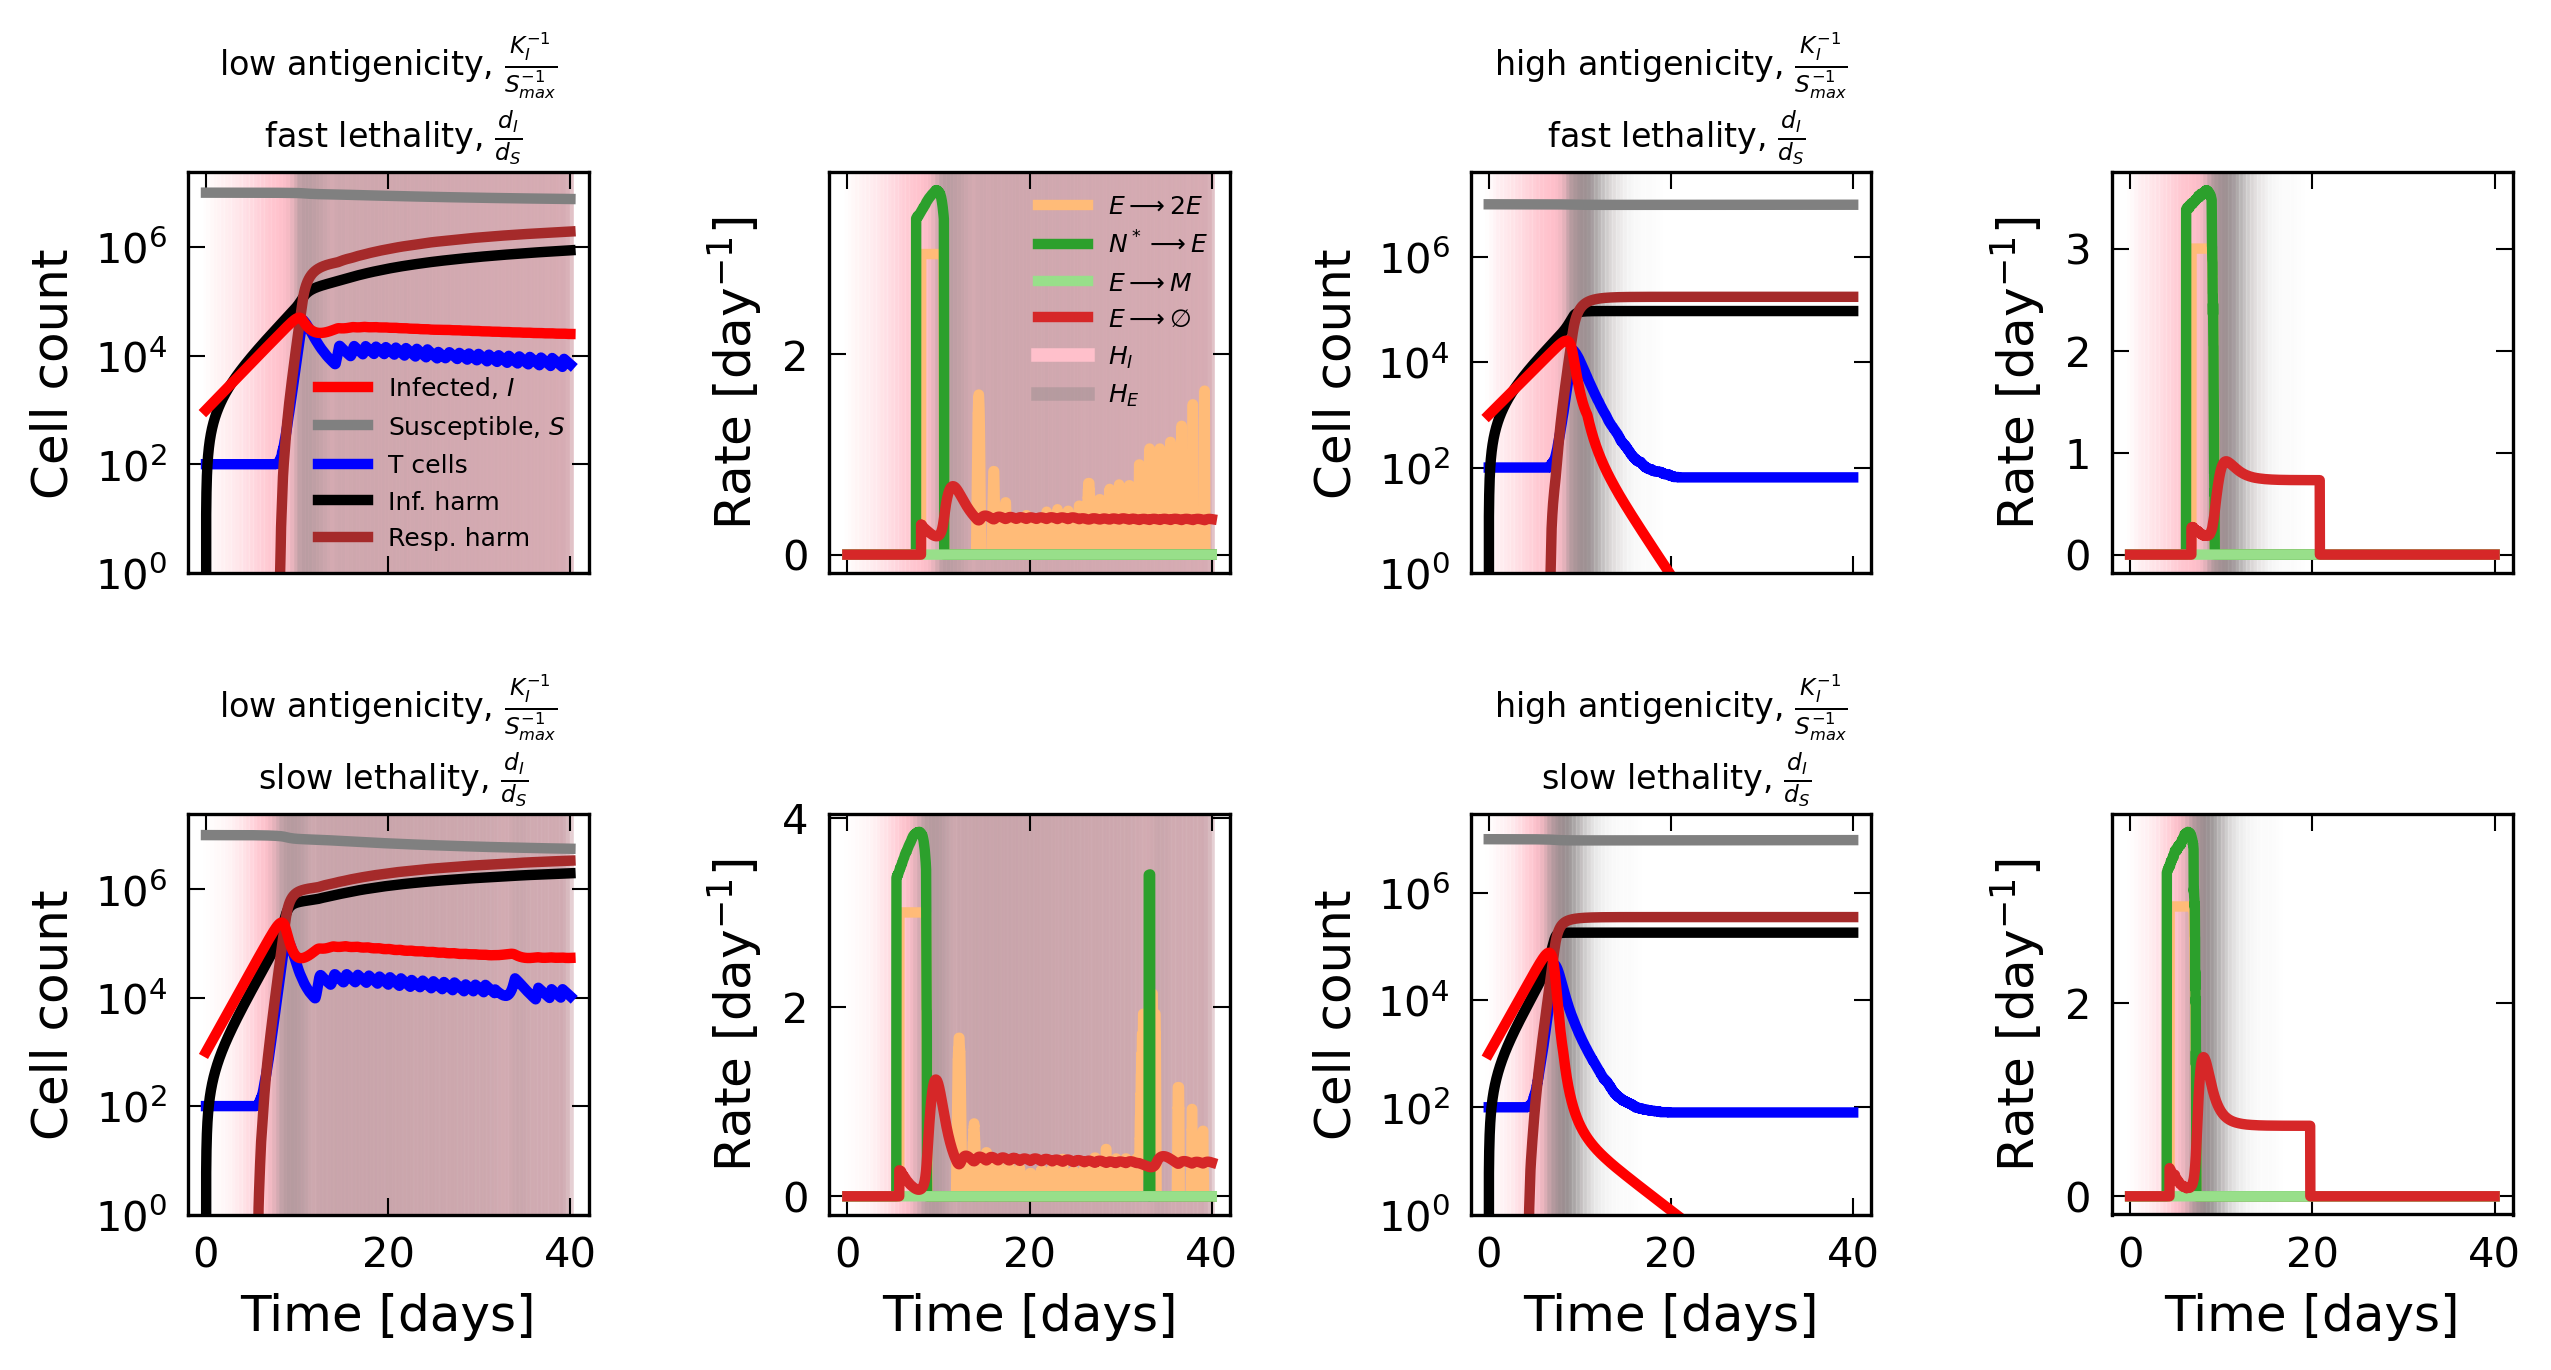

In [7]:
# Plot select infection responses
fig, axs = plt.subplots(2,4, dpi = 150, sharex = True, sharey = False, figsize=(10,5))

scenarios = np.array(np.meshgrid(np.array([heapq.nlargest(6, np.unique(infection_sample[:,0]))[4], heapq.nsmallest(6, np.unique(infection_sample[:,0]))[2]]), # vary d_I
                                 np.array([heapq.nlargest(6, np.unique(infection_sample[:,1]))[4], heapq.nsmallest(6, np.unique(infection_sample[:,1]))[2]]), # vary K_I
                                 np.array([np.amax(infection_sample[:,2])]), # vary b_I
                                 np.array([np.amax(infection_sample[:,3])]), # vary K_H
                                 np.array([np.amax(infection_sample[:,4])]), # vary N_0
                                 np.array([np.amax(infection_sample[:,5])]) # vary I_0
                                           )).T.reshape(-1,6)

var_labels = ["antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", 
              "lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
labels = ['low ' + var_labels[0]+'\n fast '+var_labels[1],
          'high ' + var_labels[0]+'\n fast '+var_labels[1],
          'low ' + var_labels[0]+'\n slow '+var_labels[1],
          'high ' + var_labels[0]+'\n slow '+var_labels[1]]
cmap_colors = sns.color_palette('tab20', 20)

# Loop and do 
for k, p in enumerate(scenarios):
    y, x = k % 2, k // 2

    # Run single simulation
    data_dict = lin_stoch_sim(N_0 = p[4],
                              I_0 = p[5],
                              b_I = p[2], 
                              K_I = p[1],
                              d_I = p[0],
                              K_H = p[3],
                              NE_regulation = NE_regulation,
                              EM_regulation = EM_regulation,
                              activation_regulation = Na_regulation,
                              contraction_regulation = Edie_regulation,
                              infection_model = 'acute',
                              reg_model = 'mwc_like',
                              out_data = "full",
                              memory_death = False)
    
    regs = data_dict["reg_coeffs"]
    dyn = data_dict["cell_time_series"]
    ts = data_dict["time"]
    lin_comp = data_dict["lineage_diff"]
    p_diff = data_dict["prim_diff_bias"]
    parameters = data_dict["parameters"]
    sim_summary = data_dict["summary_stats"]
    mycN = data_dict["N_myc_by_lin"]
    mycMa = data_dict["Ma_myc_by_lin"]
    mycE = data_dict["E_myc_by_lin"]
    Eff = data_dict["eff_by_lin"]
    T_pEcytM = data_dict["pmemory_formed"]
    
    S, I, N, Na, E, M, HI, I_d_I, I_d_S, HE = dyn[:,0], dyn[:,1], dyn[:,2], dyn[:, 3], dyn[:,4], dyn[:,5], dyn[:,6], dyn[:,7], dyn[:,8], dyn[:,9]
    
    # Plot simulated infection dynamics: pretty plots
    pnts = 100
    keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
    bias_diff = p_diff
    p_load = np.log(1 + I[keep]/K_I)/np.log(1 + np.max(I[keep])/K_I) if np.max(I[keep]) > 0 else I[keep]
    inflam = np.maximum(0, np.log((1 + HI[keep]/K_H))/np.log((1 + np.max(HI[keep])/K_H)) if np.max(HI[keep]) > 0 else HI[keep])
    anti_inflam = np.log((1 + HE[keep]/K_H))/np.log((1 + np.max(HE[keep])/K_H)) if np.max(HE[keep]) > 0 else HE[keep]
    inf_harm = I_d_I[keep]
    toxicity = I_d_S[keep]
    time = ts[keep]

    # Plot cell dynamics
    axs[x,2*y].plot(ts, I, 'r', label = r'Infected, $I$', linewidth=2.5)
    axs[x,2*y].plot(ts, S, 'grey', label = r'Susceptible, $S$', linewidth=2.5)
    axs[x,2*y].plot(ts, N + Na + E + M, 'blue', zorder = 1, linewidth=2.5, label = r'T cells')
    axs[x,2*y].plot(ts, I_d_I, 'black', zorder = 1, linewidth=2.5, label = r'Inf. harm')
    axs[x,2*y].plot(ts, I_d_S, 'brown', zorder = 1, linewidth=2.5, label = r'Resp. harm')

    axs[x,2*y].set_title(labels[k], fontsize = 8.0)
    axs[x,2*y].set_box_aspect(1)
    axs[x,2*y].semilogy()
    axs[x,2*y].minorticks_off()
    axs[x,2*y].set_ylim(1,)
    # locmaj = mpl.ticker.LogLocator(numticks=4)
    # ax.yaxis.set_major_locator(locmaj)

    # Plot cell fate transition rates
    axs[x,2*y + 1].plot(ts, bias_diff[:,0], color = cmap_colors[3], zorder = 1, linewidth=2.5, label = r'$E \longrightarrow 2E$')
    axs[x,2*y + 1].plot(ts, bias_diff[:,1], color = cmap_colors[4], zorder = 1, linewidth=2.5,label = r'$N^* \longrightarrow E$')
    axs[x,2*y + 1].plot(ts, bias_diff[:,2], color = cmap_colors[5], zorder = 1, linewidth=2.5, label = r'$E \longrightarrow M$')
    axs[x,2*y + 1].plot(ts, bias_diff[:,3], color = cmap_colors[6], zorder = 1, linewidth=2.5, label = r'$E \longrightarrow \emptyset$')

    axs[x,2*y + 1].set_box_aspect(1)
    # cb = fig.colorbar(im, ax=axs[x,2*y + 1], orientation='vertical', shrink = 0.65, pad = 0.05)
    # cb.set_label('Ag. stimulation', fontsize = 12)
    axs[x,2*y + 1].minorticks_off()
    
    for i in np.arange(0, len(inflam), 1):
        if i == np.argmax(inflam):
            axs[x,2*y].axvline(x=time[i], linestyle='-', linewidth=3.25, color='pink', alpha=inflam[i], zorder = 0) #, label =r"$H_I$")
            axs[x,2*y].axvline(x=time[i], linestyle='-', linewidth=3.25, color='grey', alpha=anti_inflam[i]/2, zorder = 0)#, label =r"$H_E$")
            axs[x,2*y + 1].axvline(x=time[i], linestyle='-', linewidth=3.25, color='pink', alpha=inflam[i], label =r"$H_I$", zorder = 0)
            axs[x,2*y + 1].axvline(x=time[i], linestyle='-', linewidth=3.25, color='grey', alpha=anti_inflam[i]/2, label =r"$H_E$", zorder = 0)
        else:
            axs[x,2*y].axvline(x=time[i], linestyle='-', linewidth=3.25, color='pink', alpha=inflam[i], zorder = 0)
            axs[x,2*y].axvline(x=time[i], linestyle='-', linewidth=3.25, color='grey', alpha=anti_inflam[i]/2, zorder = 0)
            axs[x,2*y + 1].axvline(x=time[i], linestyle='-', linewidth=3.25, color='pink', alpha=inflam[i], zorder = 0)
            axs[x,2*y + 1].axvline(x=time[i], linestyle='-', linewidth=3.25, color='grey', alpha=anti_inflam[i]/2, zorder = 0)

# cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
# fig.colorbar(im, cax=cbar_ax)

for j, ax in enumerate(axs.flat):
    if j <= 1:
        ax.legend(fontsize = 6)
    if j % 2  == 0:
        ax.set_ylabel('Cell count', fontsize = 12)
    if j % 2  == 1:
        ax.set_ylabel('Rate [day$^{-1}$]', fontsize = 12)
    if j >= 4:
        ax.set_xlabel(r"Time [days]", fontsize = 12)
fig.subplots_adjust(wspace=.6, hspace=0.25)

plt.savefig('_figs/'+infection_model+'-scenarios-of-infection-dynamics.png', dpi=150, bbox_inches="tight")

In [8]:
# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample_virs, 
    comment="single-reg-vary-virs", runs = runs, infection_model = infection_model, default_reg = default_reg, 
    num_cpu = 125)

Running 10000 simulations in batch #-1
Saved sim_batch_-1-1-acute-single-reg-vary-virs.pkl
0.046810476316346064 hrs


In [9]:
d_file = d + '/sim_batch_-1-'+str(runs)+'-'+infection_model+'-single-reg-vary-virs.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

n = len(sample_virs)
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]

In [10]:
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
sim_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).dropna(thresh=1)
use_data = sim_df #.loc[sim_df['b_I']*sim_df['S_0'] >= sim_df['d_I']]

with pd.option_context('display.max_columns', None):
    display(use_data)

,S_0,I_0,b_I,d_S,d_I,d_IE,K_I,b_H,d_H,K_H,N_0,max_Na,b_myc,d_myc,myc_thresh,t_bind,t_unbind,t_Na_div,t_E_div,t_M_div,t_E_die,t_cycle,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,p_load,T_max_pI,T_min_pI,harm_pI,harm_pS,max_pE,T_pE_max,T_pE_start,max_eM,T_pEcyteM,T_pE_end,frac_cM,int_pHE,int_pHI,sel_ratio
0,10000000.0,1000.0,5.000000e-08,0.01,0.01,12.0,1.000000e+04,1.0,2.0,10000.0,10.0,4.0,144.0,49.906597,1.0,0.5,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,2.0,-2.0,-1.5,2.0,2.0,-2.0,0.75,0.0,0.0,0.0,-27.0,-2.0,-2.0,2.0,-1.5,3.548165e+04,7.69,8.99,5.449572e+04,1.204899e+05,14669.0,8.47,5.49,0.0,0.0,17.24,0.178571,46237.458970,164.359948,0.201326
1,10000000.0,1000.0,5.000000e-08,0.01,0.01,12.0,2.154435e+04,1.0,2.0,10000.0,10.0,4.0,144.0,49.906597,1.0,0.5,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,2.0,-2.0,-1.5,2.0,2.0,-2.0,0.75,0.0,0.0,0.0,-27.0,-2.0,-2.0,2.0,-1.5,1.020307e+05,9.85,11.46,1.555734e+05,2.406170e+05,34941.0,10.56,7.64,0.0,0.0,19.82,0.206897,120691.182142,471.664239,0.138241
2,10000000.0,1000.0,5.000000e-08,0.01,0.01,12.0,4.641589e+04,1.0,2.0,10000.0,10.0,4.0,144.0,49.906597,1.0,0.5,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,2.0,-2.0,-1.5,2.0,2.0,-2.0,0.75,0.0,0.0,0.0,-27.0,-2.0,-2.0,2.0,-1.5,4.801437e+05,37.99,0.00,1.295572e+06,8.917438e+05,84947.0,38.19,8.04,0.0,0.0,40.00,0.250000,231066.501847,2246.461193,0.064409
3,10000000.0,1000.0,5.000000e-08,0.01,0.01,12.0,1.000000e+05,1.0,2.0,10000.0,10.0,4.0,144.0,49.906597,1.0,0.5,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,2.0,-2.0,-1.5,2.0,2.0,-2.0,0.75,0.0,0.0,0.0,-27.0,-2.0,-2.0,2.0,-1.5,4.487864e+05,12.96,0.00,1.958133e+06,1.423049e+06,109865.0,13.63,10.17,0.0,0.0,40.00,0.166667,230273.882588,2085.065565,0.073867
4,10000000.0,1000.0,5.000000e-08,0.01,0.01,12.0,2.154435e+05,1.0,2.0,10000.0,10.0,4.0,144.0,49.906597,1.0,0.5,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,2.0,-2.0,-1.5,2.0,2.0,-2.0,0.75,0.0,0.0,0.0,-27.0,-2.0,-2.0,2.0,-1.5,1.624049e+06,40.00,0.00,5.569582e+06,2.077545e+06,142388.0,16.40,10.85,0.0,0.0,40.00,0.219512,248309.527647,7678.968791,0.137233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,10000000.0,1000.0,2.000000e-07,0.01,1.00,12.0,4.641589e+05,1.0,2.0,10000.0,1000.0,4.0,144.0,49.906597,1.0,0.5,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,2.0,-2.0,-1.5,2.0,2.0,-2.0,0.75,0.0,0.0,0.0,-27.0,-2.0,-2.0,2.0,-1.5,9.136899e+04,4.92,0.00,1.347686e+06,3.671003e+06,351415.0,5.39,2.91,0.0,0.0,40.00,0.180923,376087.519538,39739.302946,0.168900
9996,10000000.0,1000.0,2.000000e-07,0.01,1.00,12.0,1.000000e+06,1.0,2.0,10000.0,1000.0,4.0,144.0,49.906597,1.0,0.5,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,2.0,-2.0,-1.5,2.0,2.0,-2.0,0.75,0.0,0.0,0.0,-27.0,-2.0,-2.0,2.0,-1.5,1.157922e+05,5.17,0.00,1.464075e+06,4.489092e+06,432362.0,5.52,2.87,0.0,0.0,40.00,0.180748,505852.915844,50418.353647,0.200695
9997,10000000.0,1000.0,2.000000e-07,0.01,1.00,12.0,2.154435e+06,1.0,2.0,10000.0,1000.0,4.0,144.0,49.906597,1.0,0.5,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,2.0,-2.0,-1.5,2.0,2.0,-2.0,0.75,0.0,0.0,0.0,-27.0,-2.0,-2.0,2.0,-1.5,1.486246e+05,5.44,0.00,1.509244e+06,4.821439e+06,464339.0,5.65,2.98,0.0,0.0,40.00,0.190573,656459.366219,64949.943402,0.267421
9998,10000000.0,1000.0,2.000000e-07,0.01,1.00,12.0,4.641589e+06,1.0,2.0,10000.0,1000.0,4.0,144.0,49.906597,1.0,0.5,1.0,0.366667,0.333333,0.5,10.0,0.25,2.0,2.0,-2.0,-1.5,2.0,2.0,-2.0,0.75,0.0,0.0,0.0,-27.0,-2.0,-2.0,2.0,-1.5,1.821979e+05,5.66,34.54,1.367935e+06,5.364810e+06,499520.0,5.71,3.04,0.0,0.0,20.76,0.183325,770530.014383,83290.214308,0.310289


### Understand noise structure of the simulations

In [11]:
if runs > 1:
    # Plot simulated immune dynamics
    fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))
    
    ax1.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['K_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax1.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Lethality, $d_{I}$')
    ax1.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
    ax1.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Naive, $N_0$')
    ax1.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
    ax1.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
    ax1.semilogx()
    ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    ax1.set(ylabel = 'Minumum \n suceptible fraction')
    
    ax2.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['K_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax2.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Lethality, $d_{I}$')
    ax2.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
    ax2.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Naive, $N_0$')
    ax2.semilogx()
    ax2.set(ylabel = 'Cumulative pathogen load')
    ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    
    ax3.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['K_I'], as_index=False).mean()['T_pEcyteM'], 'o--', label = 'Antigenicity, $K_{I,E}$')
    ax3.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['d_I'], as_index=False).mean()['T_pEcyteM'], 'o--', label = 'Lethality, $d_{I}$')
    ax3.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['T_pEcyteM'], 'o--', label = 'Fecundity, $b_{I}$')
    ax3.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['K_I', 'd_I', 'b_I', 'N_0'], as_index=False).std().groupby(['b_I'], as_index=False).mean()['T_pEcyteM'], 'o--', label = 'Naive, $N_0$')
    ax3.set(ylabel = 'Time in effector state', xlabel = 'Max-scaled parameter')
    ax3.semilogx()
    ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    
    
    plt.savefig('_figs/vir_parameter_lineplots_noise', dpi=300, bbox_inches='tight')

### Understand Performance distrubution of the simulations

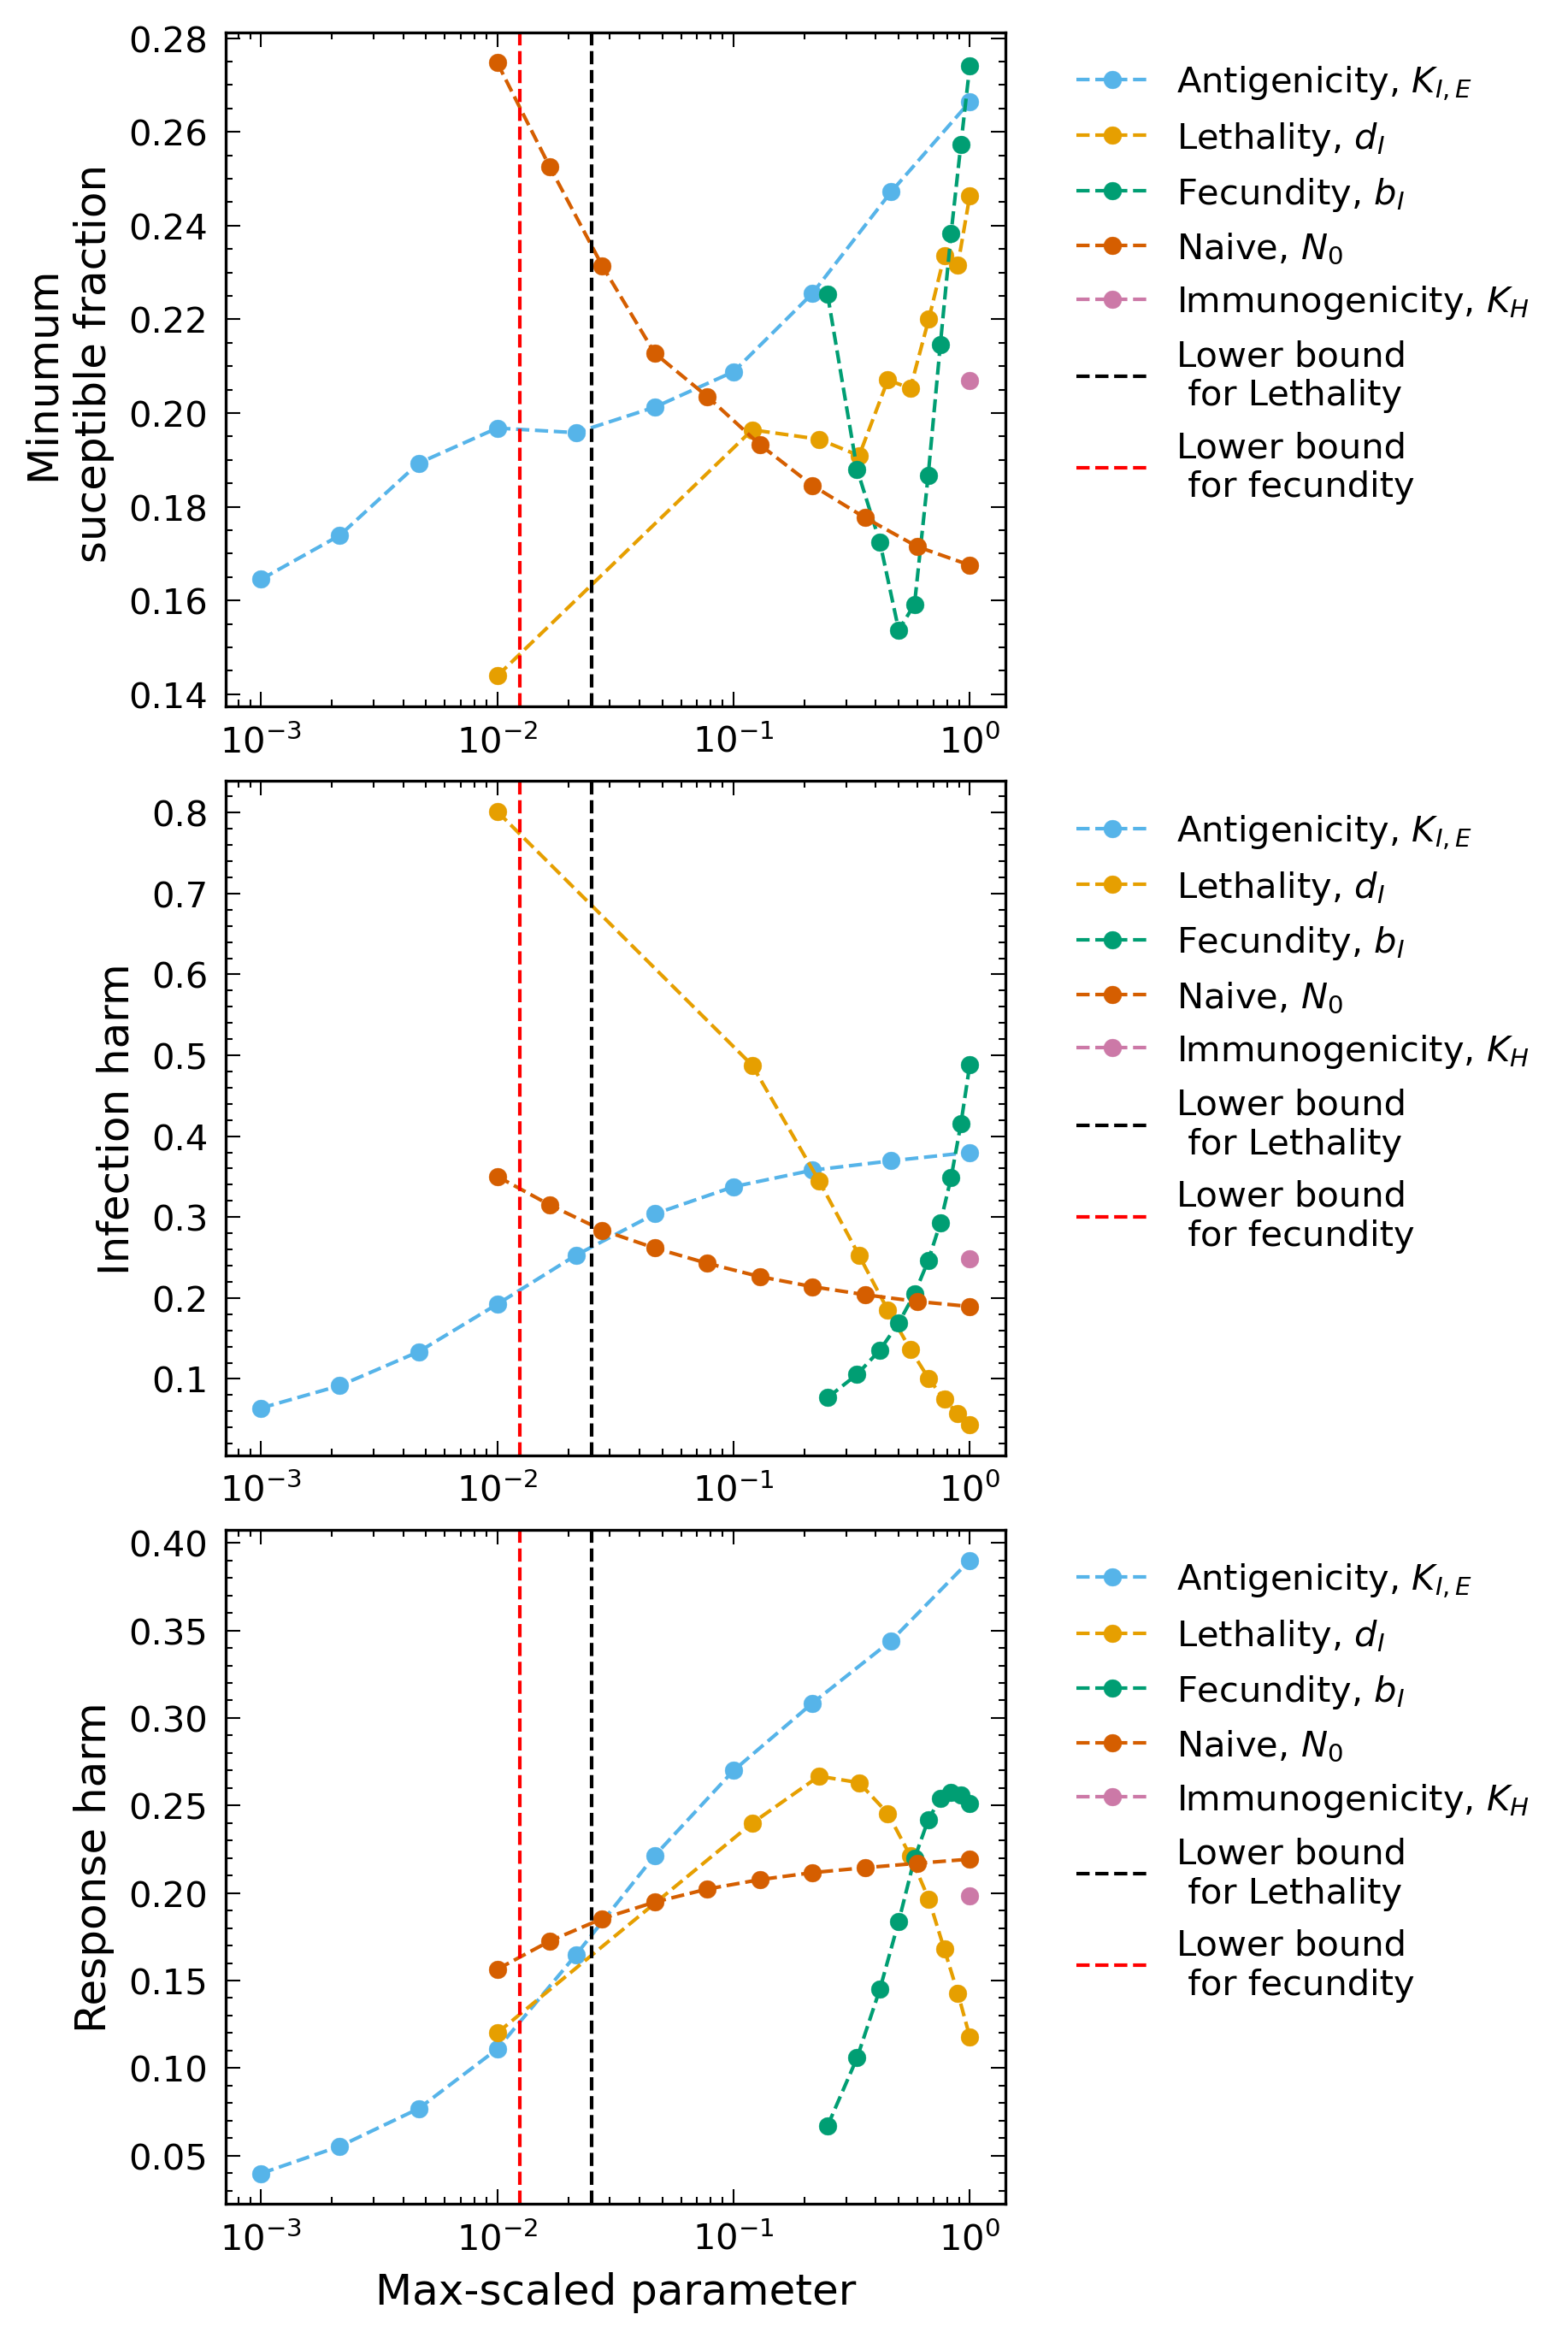

In [12]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))

ax1.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I'], as_index=False).mean()['sel_ratio'], 'o--', label = 'Antigenicity, $K_{I,E}$')
ax1.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['sel_ratio'], 'o--', label = 'Lethality, $d_{I}$')
ax1.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['sel_ratio'], 'o--', label = 'Fecundity, $b_{I}$')
ax1.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['N_0'], as_index=False).mean()['sel_ratio'], 'o--', label = 'Naive, $N_0$')
ax1.plot(use_data.groupby(['K_H'], as_index=False).mean()['K_H']/np.max(use_data['K_H']), use_data.groupby(['K_H'], as_index=False).mean()['sel_ratio'], 'o--', label = 'Immunogenicity, $K_H$')
ax1.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
ax1.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax1.semilogx()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax1.set(ylabel = 'Minumum \n suceptible fraction')

ax2.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I'], as_index=False).mean()['harm_pI']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax2.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['harm_pI']/S_0, 'o--', label = 'Lethality, $d_{I}$')
ax2.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['harm_pI']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax2.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['N_0'], as_index=False).mean()['harm_pI']/S_0, 'o--', label = 'Naive, $N_0$')
ax2.plot(use_data.groupby(['K_H'], as_index=False).mean()['K_H']/np.max(use_data['K_H']), use_data.groupby(['K_H'], as_index=False).mean()['harm_pI']/S_0, 'o--', label = 'Immunogenicity, $K_H$')
ax2.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
ax2.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax2.semilogx()
ax2.set(ylabel = 'Infection harm')
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(use_data.groupby(['K_I'], as_index=False).mean()['K_I']/np.max(use_data['K_I']), use_data.groupby(['K_I'], as_index=False).mean()['harm_pS']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax3.plot(use_data.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(use_data['d_I']), use_data.groupby(['d_I'], as_index=False).mean()['harm_pS']/S_0, 'o--', label = 'Lethality, $d_{I}$')
ax3.plot(use_data.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(use_data['b_I']), use_data.groupby(['b_I'], as_index=False).mean()['harm_pS']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax3.plot(use_data.groupby(['N_0'], as_index=False).mean()['N_0']/np.max(use_data['N_0']), use_data.groupby(['N_0'], as_index=False).mean()['harm_pS']/S_0, 'o--', label = 'Naive, $N_0$')
ax3.plot(use_data.groupby(['K_H'], as_index=False).mean()['K_H']/np.max(use_data['K_H']), use_data.groupby(['K_H'], as_index=False).mean()['harm_pS']/S_0, 'o--', label = 'Immunogenicity, $K_H$')
ax3.axvline(x = 1/sim_duration/np.max(use_data['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for Lethality")
ax3.axvline(x = 1/(sim_duration*S_0)*(1/np.max(use_data['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax3.set(ylabel = 'Response harm', xlabel = 'Max-scaled parameter')
ax3.semilogx()
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')


plt.savefig('_figs/vir_parameter_lineplots', dpi=300, bbox_inches='tight')

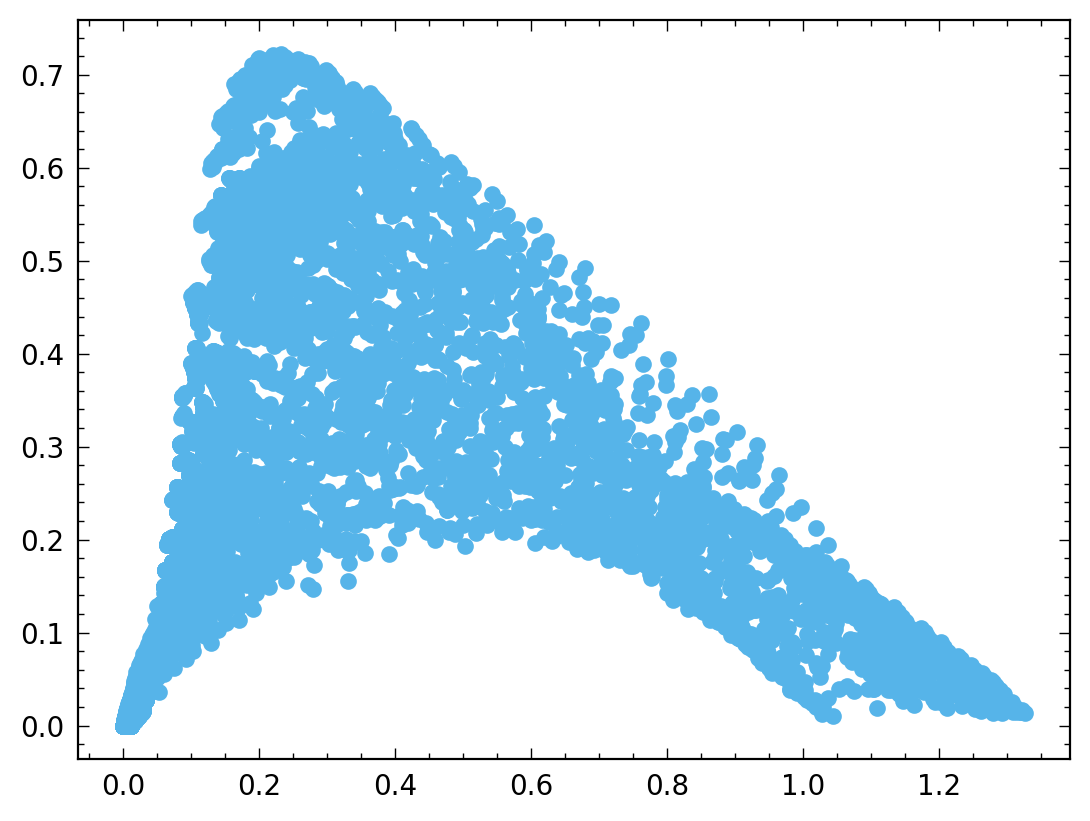

In [13]:
plt.scatter(use_data.harm_pI/S_0, use_data.harm_pS/S_0)
# plt.semilogx()
# plt.semilogy()

KeyError: 'min_pS'

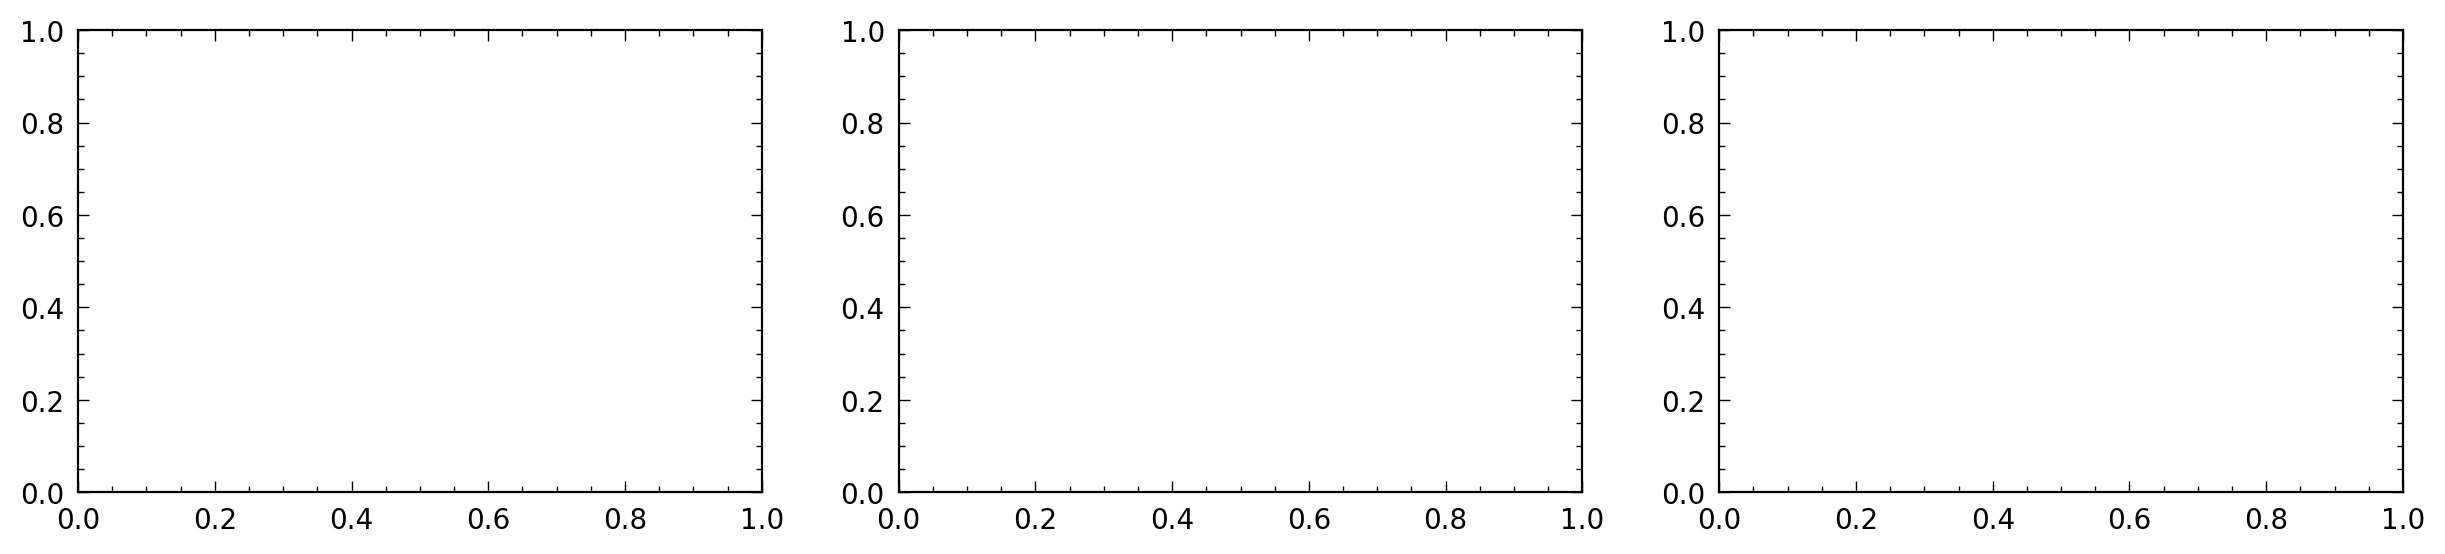

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

axs[0].tricontour(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], 
                  use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['K_I','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im0 = axs[0].tricontourf(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], 
                        use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['K_I','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="Purples", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[1].tricontour(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], 
                  use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['K_I','b_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im1 = axs[1].tricontourf(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], 
                        use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['K_I','b_I'], as_index=False).mean()['min_pS']/S_0, cmap="Purples", norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[2].tricontour(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                  use_data.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.1, colors='k')
im2 = axs[2].tricontourf(use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                        use_data.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="Purples",norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))

cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Fecundity $b_I$ vs. Lethality $d_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 12)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_contour', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(20, 3), sharex=False, sharey=False)

size = 4250/num_pnts

plot_data = use_data.groupby(['K_I','d_I'], as_index=False).mean()
im0 = axs[0].scatter(S_0/plot_data['K_I'], plot_data['d_I']/d_S, marker = 's', s = size,
                    c = plot_data['min_pS']/S_0, cmap='Purples', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label(r"Min. suceptible, $\frac{I}{S_{max}}$", fontsize = 12)

plot_data = use_data.groupby(['K_I','b_I'], as_index=False).mean()
im1 = axs[1].scatter(S_0/plot_data['K_I'], plot_data['b_I'], marker = 's', s = size,
               c = plot_data['min_pS']/S_0, cmap='Purples', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label(r"Min. suceptible, $\frac{I}{S_{max}}$", fontsize = 12)

plot_data = use_data.groupby(['b_I','d_I'], as_index=False).mean()
im2 = axs[2].scatter(plot_data['d_I']/d_S, plot_data['b_I'], marker = 's', s = size,
               c = plot_data['min_pS']/S_0, cmap='Purples', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label(r"Min. suceptible, $\frac{I}{S_{max}}$", fontsize = 12)

plot_data = use_data.groupby(['N_0','K_I'], as_index=False).mean()
im3 = axs[3].scatter(S_0/plot_data['K_I'], plot_data['N_0']/N_0, marker = 's', s = size,
               c = plot_data['min_pS']/S_0, cmap='Purples', norm=mpl.colors.Normalize(vmin= 0.0, vmax= 1))
cb = fig.colorbar(im3, ax=axs[3], orientation='vertical')
cb.set_label(r"Min. suceptible, $\frac{I}{S_{max}}$", fontsize = 12)

axs[0].set_title(r"Antigenicity, $\frac{S_{max}}{K_{I}}$ vs. Lethality, $\frac{d_I}{d_S}$", fontsize = 10)
axs[1].set_title(r"Antigenicity, $\frac{S_{max}}{K_{I}}$ vs. Fecundity, $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality, $\frac{d_I}{d_S}$ vs. Fecundity, $b_I$", fontsize = 10)
axs[3].set_title(r"Antigenicity, $\frac{S_{max}}{K_{I}}$ vs. Naive, $N_0$", fontsize = 10)

axs[0].set_ylabel(r"Lethality, $\frac{d_I}{d_S}$", fontsize = 12)
axs[0].set_xlabel(r"Antigenicity, $\frac{S_{max}}{K_{I}}$", fontsize = 12)
axs[1].set_ylabel(r"Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel(r"Antigenicity, $\frac{S_{max}}{K_{I}}$", fontsize = 12)
axs[2].set_ylabel(r"Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel(r"Lethality, $\frac{d_I}{d_S}$", fontsize = 12)
axs[3].set_ylabel(r"Naive, $N_0$", fontsize = 12)
axs[3].set_xlabel(r"Antigenicity, $\frac{S_{max}}{K_{I}}$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()
axs[3].semilogx()
axs[3].semilogy()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_heatmaps', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_I','d_I'], as_index=False).mean()['p_load']/S_0, cmap='Purples', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Relative pathogen load", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_I','b_I'], as_index=False).mean()['p_load']/S_0, cmap='Purples', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Relative pathogen load", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['p_load']/S_0, cmap='Purples', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Relative pathogen load", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}^{-1}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}^{-1}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_pharm_heatmaps', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_I','d_I'], as_index=False).mean()['T_min_pI'], cmap='Purples')
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_I','b_I'], as_index=False).mean()['T_min_pI'], cmap='Purples')
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['T_min_pI'], cmap='Purples')
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_ptiming_heatmaps', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_I','d_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['K_I','d_I'], as_index=False).mean()['harm_pI'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_I','b_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['K_I','b_I'], as_index=False).mean()['harm_pI'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pS']/use_data.groupby(['b_I','d_I'], as_index=False).mean()['harm_pI'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Toxicity", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_toxicity_heatmaps', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_I','d_I'], as_index=False).mean()['max_cM'], cmap='Purples', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_I','b_I'], as_index=False).mean()['max_cM'], cmap='Purples', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['max_cM'], cmap='Purples', norm=mpl.colors.SymLogNorm(linthresh=0.01, linscale=1))
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Initial memory", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_memory_heatmaps', dpi=300, bbox_inches='tight')

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(use_data.groupby(['K_I','d_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','d_I'], as_index=False).mean()['d_I'], marker = 's', s = size,
                    c = use_data.groupby(['K_I','d_I'], as_index=False).mean()['max_eM'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

im1 = axs[1].scatter(use_data.groupby(['K_I','b_I'], as_index=False).mean()['K_I'], use_data.groupby(['K_I','b_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['K_I','b_I'], as_index=False).mean()['max_eM'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

im2 = axs[2].scatter(use_data.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], use_data.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = size,
               c = use_data.groupby(['b_I','d_I'], as_index=False).mean()['max_eM'], cmap='Purples', norm=mpl.colors.Normalize())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Eff. memory", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Lethality $d_I$", fontsize = 10)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 10)
axs[2].set_title(r"Lethality $d_I$ vs. Fecundity $b_I$", fontsize = 10)

axs[0].set_ylabel("Lethality, $d_I$", fontsize = 12)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 12)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 12)
axs[2].set_xlabel("Lethality, $d_I$", fontsize = 12)

axs[0].semilogx()
axs[1].semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_memory_duration_heatmaps', dpi=300, bbox_inches='tight')